# 03. PyTorch Tensor와 다차원 배열





이미지 데이터는 보통 `(N, C, H, W)` 형식으로 다룬다.
`N`은 배치 크기, `C`는 채널 수, `H`와 `W`는 높이와 너비이다. 이 구조는 뒤의 CNN 수업에서 `Conv2d`가 입력을 해석하는 기준이 된다.

# PyTorch Tensor

- Tensor는 PyTorch에서 데이터를 담는 기본 단위이다.
- NumPy 배열처럼 다차원 데이터를 표현할 수 있지만, GPU 연산과 자동 미분을 지원한다는 점이 딥러닝에서 중요하다.
- 모델에 들어가는 입력, 정답, 가중치, 예측값, 손실값은 모두 Tensor로 다룬다.


## Tensor 생성과 속성 확인

Tensor는 직접 입력한 데이터, 특정 값, 난수를 이용해 만들 수 있다. 생성할 때는 필요에 따라 `dtype`과 `device`를 지정한다.

- `torch.tensor(data)`: Python 리스트와 같은 기존 데이터로 생성한다.
- `torch.zeros(shape)`, `torch.ones(shape)`: 모든 값을 0 또는 1로 채운다.
- `torch.rand(shape)`: 0 이상 1 미만의 균등분포 난수를 생성한다.
- `torch.randn(shape)`: 평균 0, 표준편차 1인 정규분포 난수를 생성한다.
- `torch.randint(low, high, shape)`: `low` 이상 `high` 미만의 정수 난수를 생성한다.
- `torch.arange(start, end, step)`: 일정한 간격의 값을 생성한다.
- `torch.zeros_like(x)`, `torch.ones_like(x)`: 기존 Tensor `x`와 같은 모양으로 생성한다.

Tensor를 만들고 나면 다음 속성을 먼저 확인한다.

- `shape` 또는 `size()`: 각 차원의 크기를 확인한다.
- `dtype`: 원소의 자료형을 확인한다. 모델 입력은 주로 `torch.float32`, 다중 분류 정답은 주로 `torch.int64`를 사용한다.
- `device`: Tensor가 CPU 또는 GPU 중 어느 장치에 있는지 확인한다.
- `dim()`: Tensor의 차원 수를 확인한다.

딥러닝에서는 Tensor의 값보다 `shape`, `dtype`, `device`가 모델의 요구사항과 맞는지 먼저 확인하는 습관이 중요하다.

In [2]:
import torch

data = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
zeros = torch.zeros(2, 3)
ones = torch.ones_like(data)
uniform = torch.rand(2, 3)
normal = torch.randn(2, 3)
integers = torch.randint(1, 10, (2, 3))
sequence = torch.arange(0, 10, 2)

print("data =", data)
print("zeros =", zeros)
print("ones_like =", ones)
print("rand =", uniform)
print("randn =", normal)
print("randint =", integers)
print("arange =", sequence)

print("shape:", data.shape)
print("size():", data.size())
print("dtype:", data.dtype)
print("device:", data.device)
print("dim():", data.dim())


data = tensor([[1., 2., 3.],
        [4., 5., 6.]])
zeros = tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones_like = tensor([[1., 1., 1.],
        [1., 1., 1.]])
rand = tensor([[0.6535, 0.1696, 0.2180],
        [0.9220, 0.3354, 0.3871]])
randn = tensor([[-0.4816,  0.0471,  0.1029],
        [ 0.5651,  0.5611, -0.1782]])
randint = tensor([[7, 2, 4],
        [7, 4, 4]])
arange = tensor([0, 2, 4, 6, 8])
shape: torch.Size([2, 3])
size(): torch.Size([2, 3])
dtype: torch.float32
device: cpu
dim(): 2


#### NumPy 배열과 Tensor 변환

PyTorch는 NumPy ndarray와 Tensor를 서로 변환해 데이터 분석 코드와 연결할 수 있다.


In [3]:
import numpy as np

x = np.array([1, 2, 3])
print(x, type(x))

# numpy -> tensor
t = torch.from_numpy(x)
print(t, type(t))

# tensor -> numpy
x2=t.numpy()
print(x2, type(x2))

[1 2 3] <class 'numpy.ndarray'>
tensor([1, 2, 3]) <class 'torch.Tensor'>
[1 2 3] <class 'numpy.ndarray'>


## 연산

#### 행렬 연산용 샘플 Tensor 준비

연산 예제에서 shape가 맞는지 먼저 확인해야 덧셈, 곱셈, 행렬곱 오류를 줄일 수 있다.

#### 원소별 사칙연산

같은 shape의 Tensor끼리는 위치가 같은 원소끼리 산술 연산을 수행한다.

#### 브로드캐스팅 연산

broadcasting은 shape가 다른 Tensor를 규칙에 맞게 확장해 연산하는 기능이다.

#### 1차원 Tensor 내적

dot, matmul, @는 1차원 벡터 내적에서 같은 스칼라 결과를 만들 수 있다.

#### 2차원 행렬곱

행렬곱은 앞 Tensor의 열 수와 뒤 Tensor의 행 수가 맞아야 계산된다.


In [4]:
a = torch.tensor([[1, 2, 3],
                  [4, 5, 6]], dtype=torch.float)
b = torch.tensor([[7, 8, 9],
                  [10, 11, 12]], dtype=torch.float)

c = torch.tensor([[1, 2],
                  [3, 4],
                  [5, 6]], dtype=torch.float)

print(a.shape, b.shape, c.shape)

print(a + b)
print(a - b)

print(a * b)

print(a / b)

print(a // b)
print(a % b)


torch.Size([2, 3]) torch.Size([2, 3]) torch.Size([3, 2])
tensor([[ 8., 10., 12.],
        [14., 16., 18.]])
tensor([[-6., -6., -6.],
        [-6., -6., -6.]])
tensor([[ 7., 16., 27.],
        [40., 55., 72.]])
tensor([[0.1429, 0.2500, 0.3333],
        [0.4000, 0.4545, 0.5000]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


In [5]:
# 브로드캐스팅

# 벡터(a) +1(스칼라)
print(a + 1) # a(2,3), 1(1,1) -> (2,3)

# 벡터(2,3) + 벡터(1,3) ->(2,3)
print(a + torch.tensor([10, 20, 30]))


tensor([[2., 3., 4.],
        [5., 6., 7.]])
tensor([[11., 22., 33.],
        [14., 25., 36.]])


In [6]:
# dot product(행렬곱 == 내적연산)

m = torch.tensor([1, 2, 3])
n = torch.tensor([4, 5, 6])

# 1차원의 내적 => 같은 idx끼리 곱
print(m.dot(n))
print(torch.dot(m, n))
print(torch.matmul(m, n))

print(m @ n)

# a(2,3) , c(3,2) -> (2,2)
print(a.matmul(c))
print(a @ c)


tensor(32)
tensor(32)
tensor(32)
tensor(32)
tensor([[22., 28.],
        [49., 64.]])
tensor([[22., 28.],
        [49., 64.]])


### 통계연산
축을 지정해서 연산하는 sum, mean, max, min등

#### dim 기준 합계 계산

dim은 어느 축을 줄일지 정하는 인자이며, 결과 shape 해석이 중요하다.

#### dim 기준 평균 계산

mean도 sum과 같은 축 개념을 사용하므로 dim별 결과 shape를 함께 확인한다.


In [7]:
"""
[[1, 2, 3],
 [4, 5, 6]]
"""

print(torch.sum(a, dim=0))
print(torch.sum(a, dim=1))
print(torch.sum(a, dim=None))



print(torch.mean(a, dim=0))
print(torch.mean(a, dim=1))
print(torch.mean(a, dim=None))


tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(21.)
tensor([2.5000, 3.5000, 4.5000])
tensor([2., 5.])
tensor(3.5000)


## 형변환
astype 대신 해당 자료형 메소드 호출

#### Tensor dtype 변환

모델 입력과 손실함수 요구사항에 맞게 float, long 같은 dtype을 맞추는 과정이 필요하다.


In [8]:
x = torch.tensor([1,2,3])
print(x, x.dtype)

# 딥러닝 모델에서 float32타입일가장많이 활용됨
print(x.float(), x.float().dtype)
print(x.double(), x.double().dtype)

print(x.int(), x.int().dtype)
# int64(long)타입은 다중분류의 label처럼 class index가 필요할때 자주사용
print(x.long(), x.long().dtype)

tensor([1, 2, 3]) torch.int64
tensor([1., 2., 3.]) torch.float32
tensor([1., 2., 3.], dtype=torch.float64) torch.float64
tensor([1, 2, 3], dtype=torch.int32) torch.int32
tensor([1, 2, 3]) torch.int64


## 형태변경

#### reshape로 Tensor 모양 변경

reshape는 전체 원소 수를 유지하면서 Tensor의 차원 구조를 바꾼다.

#### 전치와 transpose

전치는 행과 열 또는 특정 두 축을 바꾸는 연산이다.

#### flatten으로 평탄화

flatten은 여러 차원 Tensor를 1차원 형태로 펼칠 때 사용한다.

#### squeeze로 크기 1인 차원 제거

squeeze는 batch나 channel처럼 크기가 1인 차원을 제거할 때 사용한다.

#### unsqueeze로 차원 추가

unsqueeze는 모델이 요구하는 batch/channel 차원을 명시적으로 추가할 때 사용한다.


In [9]:
t = torch.arange(12) # 0-11까지 숫자 12개 1차원으로 생성

t_ = t.reshape(3, 4) # 3행 4열 (2차원으로

t_ = t.reshape(3, -1) # -1은 나머지 차원을 전체 원소 수에 맞게 알아서 자동계산
t_ = t.reshape(-1, 4)
print(t_, '\n', t_.size())

t_ = t.reshape(2, 2, 3)
print(t_, '\n', t_.size())


tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]) 
 torch.Size([3, 4])
tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]]) 
 torch.Size([2, 2, 3])


In [10]:
t = torch.arange(12).reshape(3, 4) # 0-11 3행 4열

print(t.T, '\n', t.T.shape) # T(Transpose) == pivot : 행/열 변경

# transepose(0,1) : 0번축과 1번축을 전치하라는 명시적구문
print(t.transpose(0, 1), '\n', t.transpose(0, 1).shape)

print(t.flatten()) # 평탄화: 1차원으로 변경

print(t.reshape(-1))


tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]]) 
 torch.Size([4, 3])
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]]) 
 torch.Size([4, 3])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [11]:
# 차원축소 sqeeze(): 차원의 수가 1인 차원제거
x = torch.arange(4).reshape(1,2,2)
print(x)

# x.squeeze(0) : dim=0
print(x.squeeze(0))

# x.unsqueeze(0)
x_ = x.unsqueeze(0) # 마지막차원 뒤에 새 차원추가
print(x_, x_.shape) # ([1, 1, 2, 2])

x_ = x.unsqueeze(-1) # dim=1 위치에 새 차원추가
print(x_, x_.shape) #([1, 2, 2, 1])

tensor([[[0, 1],
         [2, 3]]])
tensor([[0, 1],
        [2, 3]])
tensor([[[[0, 1],
          [2, 3]]]]) torch.Size([1, 1, 2, 2])
tensor([[[[0],
          [1]],

         [[2],
          [3]]]]) torch.Size([1, 2, 2, 1])


## indexing | slicing

#### 3차원 Tensor 준비

3차원 Tensor는 이미지, 시계열, 묶음 데이터의 축 개념을 설명하기 좋다.

#### Tensor 인덱싱

인덱싱은 특정 위치의 데이터나 하위 Tensor를 꺼내는 기본 조작이다.

#### Tensor 슬라이싱

슬라이싱은 범위를 잘라내면서 차원을 유지하거나 줄이는 방식을 비교한다.

#### Fancy Indexing

리스트나 Tensor 인덱스를 사용하면 원하는 위치의 묶음을 한 번에 선택할 수 있다.


In [12]:
x = torch.arange(1, 13).reshape(3, 2, 2)
print("원본 shape:", x.shape)
print(x)

print("x[0] shape:", x[0].shape)
print("x[1, 0]:", x[1, 0])
print("마지막 위치:", x[-1, -1, -1])

indexed = x[:, 0]
sliced = x[:, :1]
print("정수 인덱싱 shape:", indexed.shape)
# 슬라이싱은 범위를 서택하기 때문에 크기가 1이얻고 해당축을 유지한다
print("슬라이싱 shape:", sliced.shape)

selected = x[[1, 2]]
print("Fancy Indexing 결과:")
print(selected)
print("Fancy Indexing shape:", selected.shape)


원본 shape: torch.Size([3, 2, 2])
tensor([[[ 1,  2],
         [ 3,  4]],

        [[ 5,  6],
         [ 7,  8]],

        [[ 9, 10],
         [11, 12]]])
x[0] shape: torch.Size([2, 2])
x[1, 0]: tensor([5, 6])
마지막 위치: tensor(12)
정수 인덱싱 shape: torch.Size([3, 2])
슬라이싱 shape: torch.Size([3, 1, 2])
Fancy Indexing 결과:
tensor([[[ 5,  6],
         [ 7,  8]],

        [[ 9, 10],
         [11, 12]]])
Fancy Indexing shape: torch.Size([2, 2, 2])


## 유용한 메소드

#### split으로 Tensor 분할

split은 batch나 sequence를 일정 크기 단위로 나눌 때 사용한다.

#### expand로 view 기반 확장

expand는 실제 복사 없이 크기 1인 차원을 반복해 보이게 만든다.

#### expand 결과의 원본 공유 확인

expand 결과는 원본을 참조하므로 값을 바꾸면 원본에도 영향을 줄 수 있다.

#### repeat로 실제 복사 확장

repeat는 값을 실제로 복사해 독립적인 반복 Tensor를 만든다.


In [13]:
x = torch.zeros(10, 4)
print(x)

x_splits = torch.split(x, 4)

for x_ in x_splits:
    print(x_)


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [14]:

k = torch.tensor([[[1, 2]],
                  [[3, 4]]])
print(k.shape)


torch.Size([2, 1, 2])


In [15]:
# expend : 값 공유(메모리공유)

k_exp = k.expand(2, 3, 2)
print(k_exp)
print(k_exp.shape)

k_exp[0, 0, 0] = 100
print(k_exp)

print(k)


tensor([[[1, 2],
         [1, 2],
         [1, 2]],

        [[3, 4],
         [3, 4],
         [3, 4]]])
torch.Size([2, 3, 2])
tensor([[[100,   2],
         [100,   2],
         [100,   2]],

        [[  3,   4],
         [  3,   4],
         [  3,   4]]])
tensor([[[100,   2]],

        [[  3,   4]]])


In [16]:
# repeat: 복사 :
k = torch.tensor([[[1, 2]],
                  [[3, 4]]])
print(k.shape)

k_rep = k.repeat(1, 3, 1)
print(k_rep)
print(k_rep.shape)

k_rep[0, 0, 0] = 100
print(k_rep)
print(k)


torch.Size([2, 1, 2])
tensor([[[1, 2],
         [1, 2],
         [1, 2]],

        [[3, 4],
         [3, 4],
         [3, 4]]])
torch.Size([2, 3, 2])
tensor([[[100,   2],
         [  1,   2],
         [  1,   2]],

        [[  3,   4],
         [  3,   4],
         [  3,   4]]])
tensor([[[1, 2]],

        [[3, 4]]])


#### masked_fill로 조건부 값 변경

마스크 조건이 True인 위치만 특정 값으로 바꿀 수 있다.

#### Boolean Mask 인덱싱

Boolean mask를 사용하면 조건을 만족하는 원소만 꺼낼 수 있다.


In [17]:
x = torch.arange(9).reshape(3, -1)
print(x)

mask = x > 4
print(mask)

x_ = x.masked_fill(mask, value=0)
print(x_)

x[mask]


tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
tensor([[False, False, False],
        [False, False,  True],
        [ True,  True,  True]])
tensor([[0, 1, 2],
        [3, 4, 0],
        [0, 0, 0]])


tensor([5, 6, 7, 8])

## 모델 학습에서 Tensor 다차원 배열 연산

신경망의 한 층은 입력 Tensor를 받아 선형 계산을 수행하고, 활성화 함수를 적용해 다음 층으로 전달한다.
아래에서는 같은 계산을 Tensor로 직접 구현한 뒤 `nn.Module` 기반 모델로 다시 구현한다.

---

#### Linear 계산

Linear 계산은 입력 특성에 가중치를 곱하고 편향을 더해 새로운 특성을 만드는 연산이다. 완전연결층 또는 선형층이라고도 한다.

```python
z = X @ W + b
```

- `X`: 모델에 넣는 입력 데이터이다. shape는 `(batch_size, input_dim)`이다.
- `W`: 입력 특성과 출력 노드를 연결하는 가중치이다. 직접 `X @ W`를 계산할 때 shape는 `(input_dim, output_dim)`이다.
- `b`: 출력 노드마다 더하는 편향이다. shape는 `(output_dim,)`이며 배치의 모든 데이터에 브로드캐스팅된다.
- `z`: 선형 계산 결과이다. shape는 `(batch_size, output_dim)`이다.

`nn.Linear(input_dim, output_dim)`을 사용하면 PyTorch가 가중치와 편향을 자동으로 생성한다.
단, `nn.Linear` 내부의 가중치는 `(output_dim, input_dim)` 형태로 저장되며, 순전파할 때 내부적으로 `X @ W.T + b`를 계산한다.

```
- 순전파: 현재 가중치로 입력부터 예측값까지 계산.
- 역전파: 손실을 기준으로 각 가중치의 기울기를 계산.
- 가중치 업데이트: optimizer가 기울기를 이용해 가중치를 수정.
```

---

#### ReLU

ReLU는 **Rectified Linear Unit**의 약자로, 선형 계산 결과에 비선형성을 추가하는 활성화 함수이다.

```python
output = max(0, z)
```

- `z`가 0보다 크면 값을 그대로 사용한다.
- `z`가 0 이하이면 0으로 바꾼다.
- Linear 계산만 여러 번 연결하면 전체 모델도 하나의 선형 계산과 같아진다. ReLU를 넣으면 신경망이 단순한 직선으로 구분하기 어려운 패턴도 학습할 수 있다.

PyTorch에서는 `torch.relu(z)` 또는 `nn.ReLU()(z)`로 사용할 수 있다.

---

#### nn.Module

- `nn.Module`은 PyTorch에서 신경망 모델을 만들 때 상속하는 기본 클래스이다.
- 모델 안에 선언한 `nn.Linear` 같은 계층을 자동으로 등록한다.
- 계층의 가중치와 편향을 학습 대상 파라미터로 추적한다.
`__init__()`에는 사용할 계층을 만들고, `forward()`에는 입력 데이터가 계층을 통과하는 순서를 작성한다.

In [24]:
import torch.nn as nn

X = torch.randn(4, 5)

W = torch.randn(5, 3)
b = torch.randn(3)
manual_output = torch.relu(X @ W + b)
print("직접 계산 결과 shape:", manual_output.shape)


직접 계산 결과 shape: torch.Size([4, 3])


In [25]:
# nn.Module

class SimplNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        # Linear는 W(가중치), b(편향)를 자동으로 학습대상 파라미터로 등록
        self.linear = nn.Linear(input_dim,output_dim)

        # 활성화함수
        self.relu = nn.ReLU()

    # 순전파 : 모델의 동작순서
    def forward(self, x):
        z = self.linear(x)
        return self.relu(z)


model = SimplNet(input_dim=5, output_dim=3)
model_output = model(X)

# W도 입력값처럼 (5,3)인데 내적연산이 수행되지 않기 때문에 내부적으로 전치 수행
print('모델 계산 결과의 shape: ', manual_output.shape)
print('모델의 가중치 shape: ', model.linear.weight.shape)
print('모델의 편향의 shape: ', model.linear.bias.shape)

모델 계산 결과의 shape:  torch.Size([4, 3])
모델의 가중치 shape:  torch.Size([3, 5])
모델의 편향의 shape:  torch.Size([3])


## 실습: 다층 신경망 순전파 구현

입력 특성 10개를 은닉 노드 8개로 변환한 뒤 클래스 4개의 출력으로 변환한다.

### 문제 1. Tensor로 직접 계산

1. `X = torch.randn(6, 10)`으로 샘플 6개를 만든다.
2. `W1`, `b1`을 이용해 은닉층의 선형 계산을 수행한다.
3. 은닉층에 `tanh` 활성화 함수를 적용한다.
4. `W2`, `b2`를 이용해 클래스 4개의 출력값을 계산한다.
5. `softmax(dim=1)`을 적용해 샘플별 확률 합이 1인지 확인한다.

### 문제 2. nn.Module로 구현

1. `nn.Linear(10, 8)`과 `nn.Linear(8, 4)`를 정의한다.
2. `forward()`에서 첫 번째 Linear, tanh, 두 번째 Linear 순서로 계산한다.
3. 모델의 출력 `shape`와 예측 클래스를 확인한다.
4. `named_parameters()`로 계층별 가중치와 편향의 이름 및 `shape`를 확인한다.

실제 다중 분류 학습에서 `CrossEntropyLoss`를 사용할 때는 모델이 softmax 확률이 아니라 **logits**를 반환해야 한다. 확률이 필요한 평가 단계에서만 softmax를 적용한다.


### Tensor로 직접 다층 계산

첫 번째 가중치 `W1`은 입력 특성 10개를 은닉 노드 8개로 연결한다. 두 번째 가중치 `W2`는 은닉 노드 8개를 클래스 출력 4개로 연결한다.

각 층에서 `입력 @ 가중치 + 편향`을 계산하며, 은닉층에는 비선형성을 만들기 위해 tanh를 적용한다.


In [26]:
X = torch.randn(6, 10)

W1 = torch.randn(10, 8)
b1 = torch.randn(8)
hidden = torch.tanh(X @ W1 + b1)

W2 = torch.randn(8, 4)
b2 = torch.randn(4)
logits = hidden @ W2 + b2

probabilities = torch.softmax(logits, dim=1)

print("은닉층 shape:", hidden.shape)
print("logits shape:", logits.shape)
print("확률 shape:", probabilities.shape)
print("샘플별 확률 합:", probabilities.sum(dim=1))
print("예측 클래스:", probabilities.argmax(dim=1))


은닉층 shape: torch.Size([6, 8])
logits shape: torch.Size([6, 4])
확률 shape: torch.Size([6, 4])
샘플별 확률 합: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
예측 클래스: tensor([2, 2, 2, 0, 3, 2])


### 같은 구조를 nn.Module로 구현

직접 만든 `W1`, `b1`, `W2`, `b2`를 두 개의 `nn.Linear` 계층으로 바꾼다.

- `__init__()`: 모델이 사용할 계층과 활성화 함수를 생성한다.
- `forward()`: 입력이 계층을 통과하는 순서를 작성한다.
- `named_parameters()`: PyTorch가 추적하는 가중치와 편향의 이름 및 shape를 확인한다.

모델은 학습에 사용할 logits를 반환하고, 예측 확률이 필요할 때 모델 밖에서 softmax를 적용한다.


In [27]:
class MultiLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.Tanh()
        self.output = nn.Linear(hidden_dim, output_dim)
        # 출력층 활성화함수 작성 x

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)
        x = self.output(x)
        return x

model = MultiLayerNet(input_dim=10, hidden_dim=8, output_dim=4)
logits = model(X) # 출력층 결과, 아직 활성화함수 통과 x == 선형방전식 결과

# logits을 활성화함수 통과시키기
 # 출력결과가 4개 == 다중분류 필요 -> softmax 사용

probabilities = torch.softmax(logits, dim=1)
print('logits shape : ', logits.shape)
print('예측클래스 : ', probabilities.argmax(dim=1))



logits shape :  torch.Size([6, 4])
예측클래스 :  tensor([3, 0, 2, 3, 1, 0])


## 이미지 Tensor의 축과 시각화

- N (Batch Size, 배치 크기): 한 번에 모델에 입력되는 이미지의 개수
예를 들어 N = 32라면, 32장의 이미지를 묶어서 한 번에 처리하겠다는 뜻

- C (Channels, 채널 수): 이미지의 색상 정보 차원
흑백(Grayscale) 이미지는 채널이 1개 (명암)
일반적인 컬러(RGB) 이미지는 채널이 3개 (Red, Green, Blue)

- H (Height, 세로 해상도): 이미지의 세로 픽셀 수

- W (Width, 가로 해상도): 이미지의 가로 픽셀 수

PyTorch와 Matplotlib은 컬러 이미지의 채널 위치를 다르게 사용한다.

- PyTorch 이미지 한 장: `(C, H, W)`
- PyTorch 이미지 여러 장: `(N, C, H, W)`
- Matplotlib 이미지 한 장: `(H, W, C)`
- Matplotlib 이미지 여러 장: `(N, H, W, C)`

`permute()`는 데이터를 복사하지 않고 축의 순서를 재배치한다. PyTorch 이미지 한 장을 시각화할 때는 `image.permute(1, 2, 0)`으로 CHW를 HWC로 바꾼다.

채널 축의 평균을 계산하면 `(H, W)` 형태의 간단한 흑백 이미지를 만들 수 있다. 밝기를 바꿀 때는 값이 0과 1의 범위를 벗어나지 않도록 `clamp()`를 사용한다.


배치 이미지 shape: torch.Size([3, 3, 32, 32])
이미지 한 장 shape: torch.Size([3, 32, 32])
흑백 이미지 shape: torch.Size([32, 32])


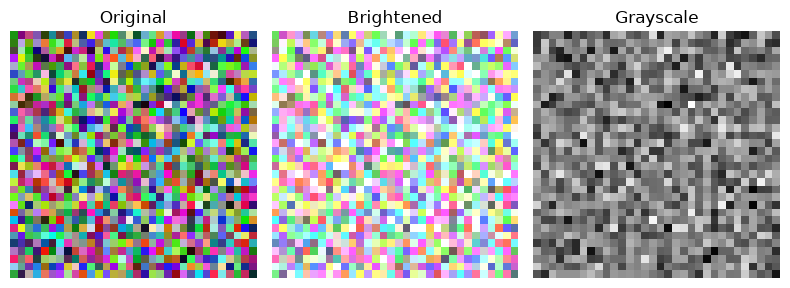

시각화용 배치 shape: torch.Size([3, 32, 32, 3])


In [28]:
import matplotlib.pyplot as plt

batch_size, channels, height, width = 3, 3, 32, 32
images = torch.rand(batch_size, channels, height, width)

first_image = images[0]
gray_image = first_image.mean(dim=0)
bright_image = (first_image + 0.3).clamp(0, 1)

print("배치 이미지 shape:", images.shape)
print("이미지 한 장 shape:", first_image.shape)
print("흑백 이미지 shape:", gray_image.shape)

original_hwc = first_image.permute(1, 2, 0)
bright_hwc = bright_image.permute(1, 2, 0)

plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(original_hwc)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bright_hwc)
plt.title("Brightened")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

images_nhwc = images.permute(0, 2, 3, 1)
print("시각화용 배치 shape:", images_nhwc.shape)
